# 02 — Análisis Exploratorio

Se explora visualmente el dataset para entender qué información contienen las radiografías
antes de cualquier extracción de características. Las preguntas que se responden acá:

- ¿Las imágenes de distintas clases se ven diferentes a ojo?
- ¿Hay diferencias en la distribución de intensidad entre clases?
- ¿Qué métricas básicas de intensidad separan mejor las clases?

In [1]:
import os
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.stats import entropy as scipy_entropy

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

In [2]:
# Ajustar DATA_ROOT según entorno
DATA_ROOT  = os.path.join(os.path.expanduser('~'), '.cache', 'kagglehub',
                          'datasets', 'usmanshams', 'tbx-11', 'versions', '1', 'TBX11K')
IMG_SIZE   = (256, 256)
LABEL_MAP  = {'health': 0, 'sick': 1, 'tb': 2}
VALID_EXTS = ('.png', '.jpg', '.jpeg')
PALETTE    = {'health': '#4CAF50', 'sick': '#FF9800', 'tb': '#F44336'}

# Carga del DataFrame base
records = []
imgs_dir = Path(DATA_ROOT) / 'imgs'
for class_name, label in LABEL_MAP.items():
    class_dir = imgs_dir / class_name
    if not class_dir.is_dir():
        continue
    for f in class_dir.iterdir():
        if f.suffix.lower() in VALID_EXTS:
            records.append({'image_path': str(f), 'class_name': class_name, 'label': label})

df_base = pd.DataFrame(records)
print(f'Imágenes cargadas: {len(df_base)}')

Imágenes cargadas: 8400


---
## 1. Visualización de ejemplos por clase

Primera mirada a las radiografías. Se muestran 4 imágenes por clase para ver si
hay diferencias visibles a ojo entre `health`, `sick` y `tb`.

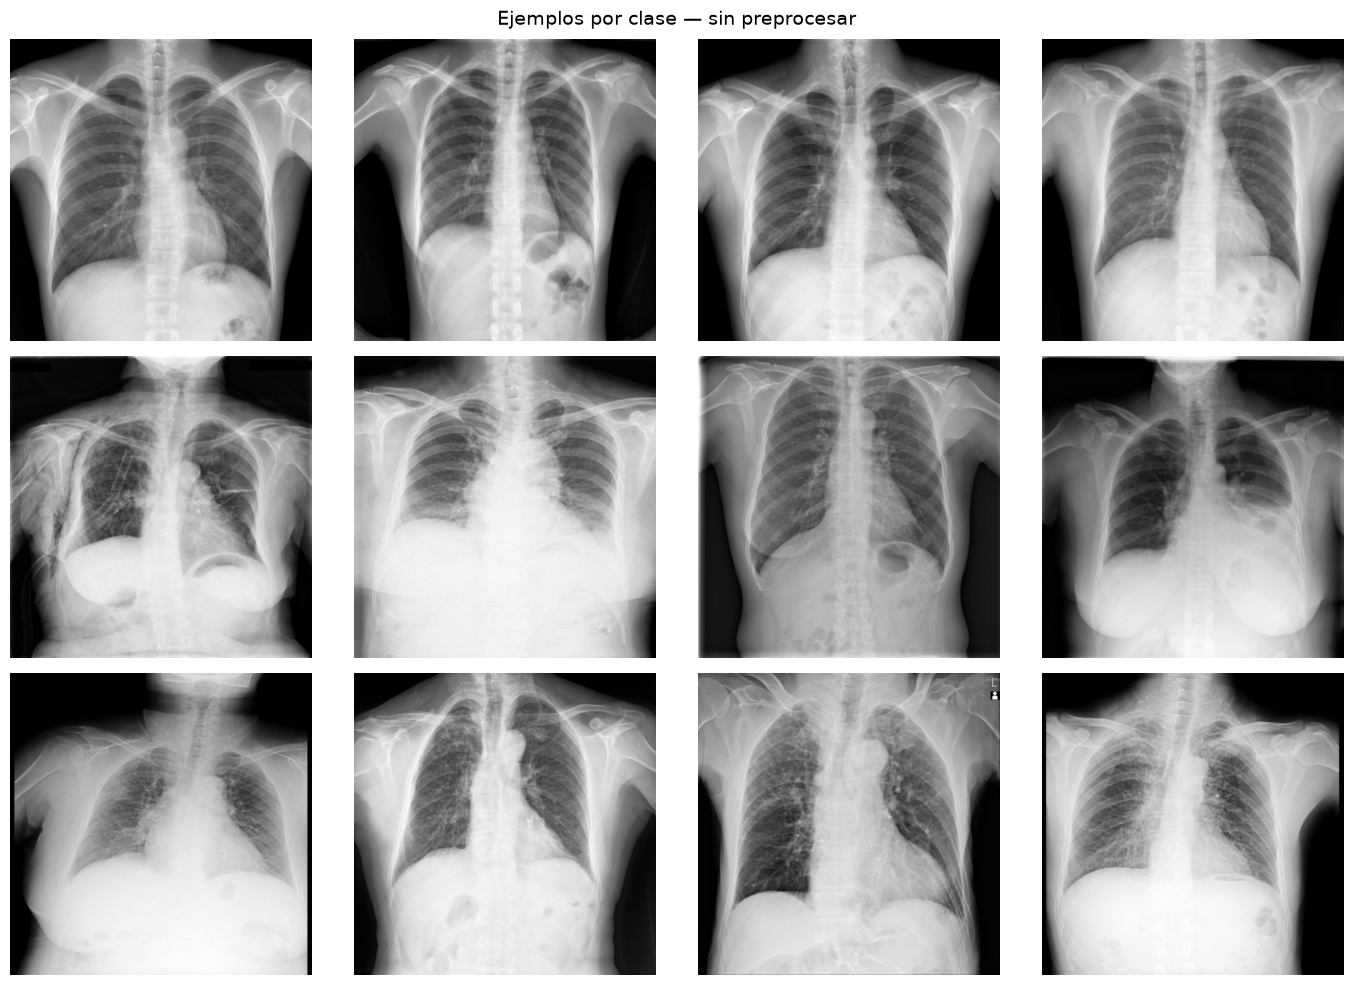

In [3]:
N = 4
fig, axes = plt.subplots(3, N, figsize=(14, 10))

for row, class_name in enumerate(['health', 'sick', 'tb']):
    muestras = df_base[df_base['class_name'] == class_name].sample(N, random_state=42)
    for col, (_, sample) in enumerate(muestras.iterrows()):
        img = cv2.imread(sample['image_path'], cv2.IMREAD_GRAYSCALE)
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(class_name, fontsize=13, fontweight='bold')

plt.suptitle('Ejemplos por clase — sin preprocesar', fontsize=14)
plt.tight_layout()
plt.show()

---
## 2. Histogramas de intensidad por clase

El histograma muestra cuántos píxeles hay de cada nivel de gris (0=negro, 255=blanco).
Si las curvas de las tres clases difieren, la distribución de brillo contiene
información discriminativa.

Se trabaja sobre imágenes **sin preprocesar** a propósito — el objetivo es ver
las diferencias brutas entre clases, no el efecto del preprocesamiento
(eso se analiza en `03_Preprocesamiento.ipynb`).

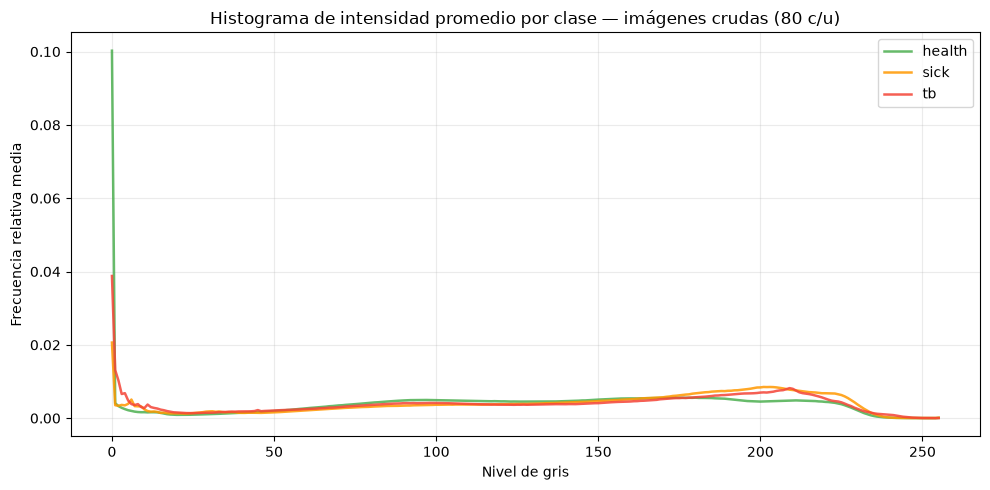

In [4]:
N_HIST = 80

plt.figure(figsize=(10, 5))

for class_name, color in PALETTE.items():
    muestras  = df_base[df_base['class_name'] == class_name].sample(N_HIST, random_state=42)
    hist_acum = np.zeros(256)
    for _, row in muestras.iterrows():
        img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        h = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
        hist_acum += h / h.sum()
    hist_acum /= N_HIST
    plt.plot(hist_acum, color=color, label=class_name, linewidth=1.8, alpha=0.85)

plt.title(f'Histograma de intensidad promedio por clase — imágenes crudas ({N_HIST} c/u)')
plt.xlabel('Nivel de gris')
plt.ylabel('Frecuencia relativa media')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

---
## 3. Métricas de intensidad por clase

Se calculan cuatro métricas sobre la distribución de intensidad de cada imagen:

- **mean** — brillo promedio global
- **std** — variabilidad de brillo
- **contrast** — diferencia entre píxel más brillante y más oscuro
- **entropy** — desorden del histograma — lesiones aumentan la heterogeneidad

Fuente: `CAD_Analisis_Exploratorio.ipynb`.

In [5]:
stats = []
for class_name in ['health', 'sick', 'tb']:
    muestras = df_base[df_base['class_name'] == class_name].sample(N_HIST, random_state=42)
    for _, row in muestras.iterrows():
        img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        h      = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
        h_norm = h / (h.sum() + 1e-9)
        stats.append({
            'class_name': class_name,
            'mean':       float(np.mean(img)),
            'std':        float(np.std(img)),
            'contrast':   float(int(img.max()) - int(img.min())),
            'entropy':    float(scipy_entropy(h_norm + 1e-9)),
        })

stats_df = pd.DataFrame(stats)
print('Promedios por clase:')
print(stats_df.groupby('class_name')[['mean','std','contrast','entropy']].mean().round(2))

Promedios por clase:
              mean    std  contrast  entropy
class_name                                  
health      121.76  65.36    238.74     5.03
sick        143.27  61.79    231.66     5.11
tb          130.66  68.62    242.51     5.14


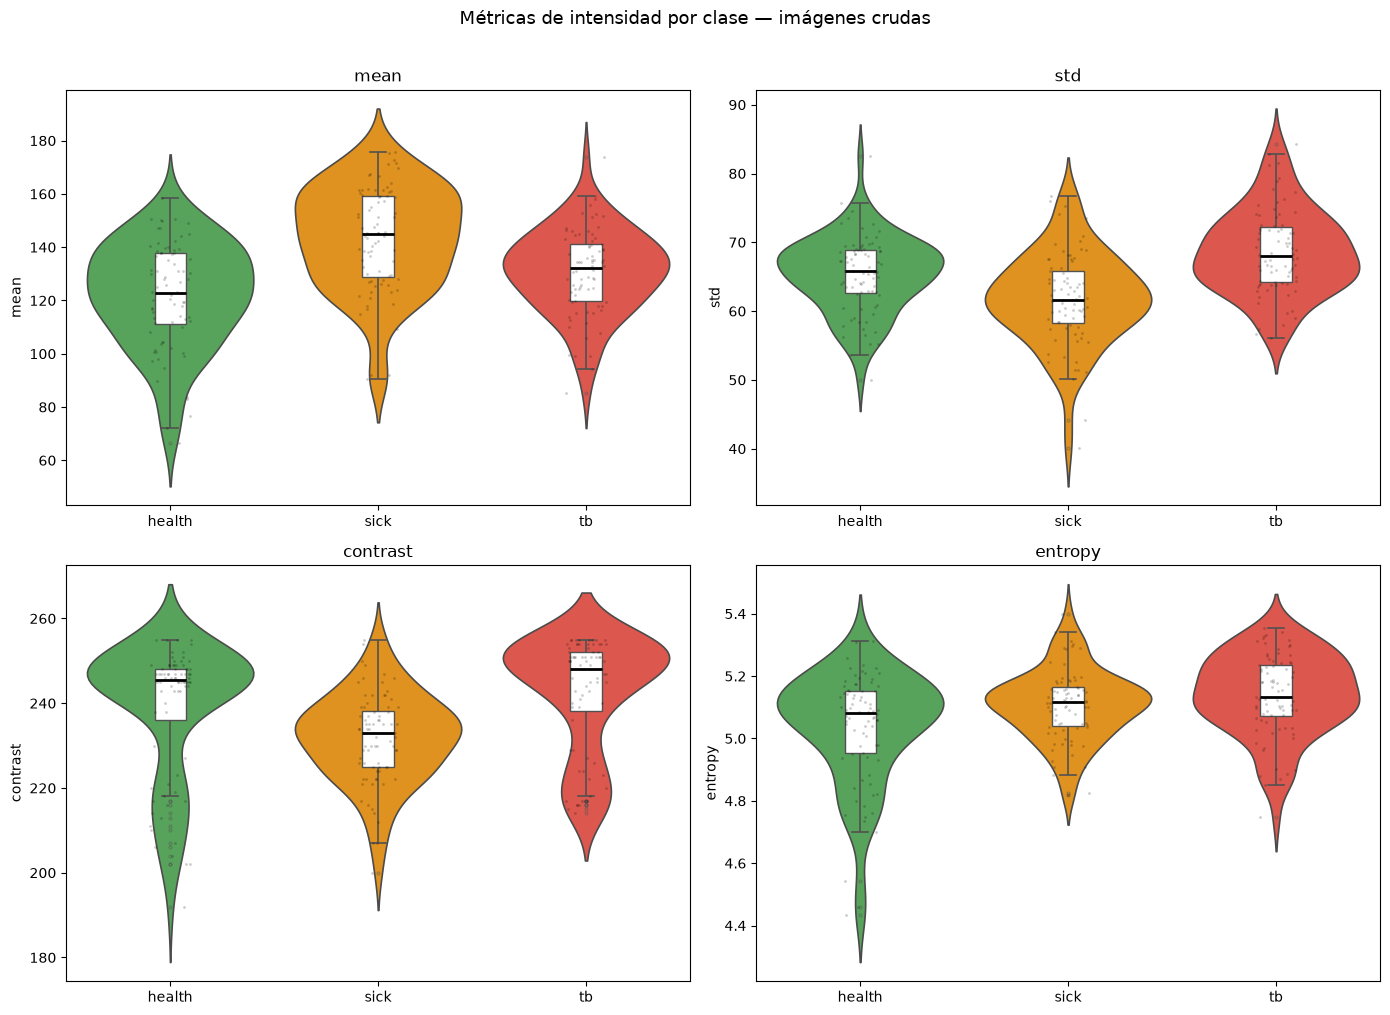

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, ['mean', 'std', 'contrast', 'entropy']):
    sns.violinplot(
        data=stats_df, x='class_name', y=col,
        order=['health','sick','tb'], palette=PALETTE,
        inner=None, linewidth=1.2, ax=ax
    )
    sns.boxplot(
        data=stats_df, x='class_name', y=col,
        order=['health','sick','tb'], width=0.15,
        boxprops=dict(facecolor='white', zorder=2),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=2, alpha=0.4),
        ax=ax
    )
    sns.stripplot(
        data=stats_df, x='class_name', y=col,
        order=['health','sick','tb'],
        color='black', alpha=0.2, size=2, jitter=True, ax=ax
    )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')

plt.suptitle('Métricas de intensidad por clase — imágenes crudas', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()